# Numerical Simulation Laboratory - Exercise 04

## INTRODUCTION

### Microcanonical ensemble and equations of motion

The aim of this exercise is to study the Molecular Dynamics simulation of a Lennard-Jones fluid in the **microcanonical ensemble**, i.e. at constant number of particles, volume and total energy.

In the **NVE** ensemble, the microscopic dynamics is governed by Newton's equations,

$$
m\ddot{\vec r}_i = \vec F_i = -\nabla_i V,
$$

or, in the reduced units used in the simulation and for unit particle mass,

$$
\ddot{\vec r}_i = \vec a_i = \vec F_i.
$$

The system evolves deterministically from the initial positions and velocities of the particles, while the **total energy should remain conserved** apart from small numerical integration errors. Since the system is isolated, the temperature is not imposed by a thermostat during the evolution, contrary to what happens in the canonical ensemble: it is obtained from the kinetic energy and can fluctuate in time.

### Lennard-Jones interaction and periodic boundary conditions

The interaction between particles is described by the **Lennard-Jones potential**, written in reduced units as

$$
V(r)=4\left[\left(\frac{1}{r}\right)^{12}-\left(\frac{1}{r}\right)^6\right].
$$

The repulsive term dominates at short distances, while the attractive term is relevant at intermediate distances.

**Periodic boundary conditions** are used to reduce surface effects due to the finite number of simulated particles. The simulation box is replicated periodically in all spatial directions, so that the particles in the central box represent a small part of an infinite periodic system. When a particle crosses one side of the box, its periodic image enters from the opposite side. In this way there are no physical walls and no special surface particles.

When distances between particles are computed, the closest periodic image is used. This is the **minimum image convention**: each particle can interact with many other particles, but for each pair the interaction is evaluated using the nearest periodic copy of the other particle. Since the Lennard-Jones interaction is short-ranged, forces and potential energy are evaluated only when this minimum-image distance is smaller than the cutoff radius $r_c$.

For example, if one particle is close to the right side of the box and another one is close to the left side, their distance is not considered to be almost the full box length. Due to periodic boundary conditions, the two particles are close through the boundary, so the minimum-image distance is used.

### Verlet algorithm

The equations of motion are integrated with the **Verlet algorithm**. This method updates the position of each particle according to

$$
\vec r(t+\Delta t)=2\vec r(t)-\vec r(t-\Delta t)+\vec a(t)\Delta t^2+O(\Delta t^4).
$$

The term $O(\Delta t^4)$ comes from the Taylor expansion used to derive the algorithm and represents the local truncation error of the position update. The acceleration is obtained from the Lennard-Jones forces evaluated at the current particle positions. In reduced units and for unit particle mass, one has $\vec a_i(t)=\vec F_i(t)$, where the force is the negative gradient of the Lennard-Jones potential, $\vec F_i(t)=-\nabla_i V$. A useful feature of Verlet integration is that it does not require the velocities explicitly to advance the positions. However, velocities are needed to compute the kinetic energy, the temperature and the speed distribution. They can be reconstructed through the centered finite-difference formula

$$
\vec v(t) \simeq \frac{\vec r(t+\Delta t)-\vec r(t-\Delta t)}{2\Delta t}.
$$

Since the update requires both $\vec r(t)$ and $\vec r(t-\Delta t)$, the Verlet algorithm is a two-step method and is **not self-starting**. Initial positions and velocities are not sufficient to apply the Verlet update directly: when `RESTART = 0`, the code uses the generated velocities to construct an approximate previous-time-step configuration. Instead, when the simulation is restarted with `RESTART = 1`, two successive configurations are already required. This is the role of the `config.xyz` and `conf-1.xyz` files: they contain the positions at two consecutive time steps and provide the information needed to continue the Verlet integration without generating a new set of initial velocities.

The same two-step structure is also important for time reversal. The Verlet algorithm is properly centered: $\vec r(t-\Delta t)$ and $\vec r(t+\Delta t)$ play symmetrical roles in the update formula. For this reason, the Verlet scheme is **time-reversal invariant** in principle. This symmetry is one of the reasons why Verlet is well suited for microcanonical Molecular Dynamics simulations. The total energy is not conserved exactly at each numerical step because the trajectory is integrated with a finite time step and is also affected by small round-off errors. However, for a sufficiently small time step, the numerical energy remains stable, showing only small bounded fluctuations rather than a systematic drift.

### Velocity distribution

In this exercise the velocity distribution $P(v)$ is added to the Molecular Dynamics code. The measured distribution is compared with the Maxwell-Boltzmann distribution,

$$
P(v)=4\pi v^2\left(\frac{1}{2\pi T}\right)^{3/2}
e^{-v^2/(2T)},
$$

in reduced units and for particle mass equal to one. This comparison is useful to check whether the molecular dynamics produces the expected equilibrium distribution of particle speeds.

## EXERCISE 04.1

### Assignment prompt

In Statistical Mechanics the Maxwell–Boltzmann distribution (<a href="https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution" target="_blank">Link Wikipedia</a>) is a probability distribution used for describing particle speeds in idealized gases. However, rarefied gases at ordinary temperatures behave very nearly like an ideal gas and the Maxwell–Boltzmann speed distribution is an excellent approximation for such gases. For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The NSL_SIMULATOR code already computes the total (internal) energy per particle, $E/N$, the potential energy per particle, $U/N$, the kinetic energy per particle, $K/N$, the temperature, $T$, and the pressure, $P$.

Include the calculation of the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, inside your Molecular Dynamics code by using data blocking to obtain single block averages, progressive average values and progressive uncertainties for $p(v^*,T^*)$.

Remember that, the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, can be approximately computed as a **normalized histogram** on an appropriate interval $\left[ 0, v_{max}\right]$ and chosing the number of bins into which you want to divide this interval.

### Method

The aim of this first part is to add the measurement of the speed distribution to the Molecular Dynamics code. The simulation used here is an LJ Molecular Dynamics run with the following input parameters:

```text
SIMULATION_TYPE        0
RESTART                1
TEMP                   1.1
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.001
NBLOCKS                20
NSTEPS                 2000
```

The property file contains

```text
POFV 30
```

so the distribution of the velocity modulus is accumulated using 30 bins.

The simulation is performed with `RESTART = 1`, using the two configuration files provided with the exercise, `config.xyz` and `conf-1.xyz`. These files contain the particle positions at two successive time steps and provide the information required by the Verlet algorithm to start the Molecular Dynamics evolution.

In Molecular Dynamics the block index also has a temporal meaning, because the blocks are consecutive time windows of the same trajectory. The simulation does not restart at the beginning of each block: particle positions and velocities continue evolving continuously. Only the statistical accumulators are reset. Therefore, `ACTUAL_POFV` represents the estimate obtained within a single time window, while `AVE_POFV` is the progressive average over all blocks up to the selected one.

This part of the exercise is therefore used to test the implementation of the new observable `POFV` in a standard restarted MD run, before moving to the special low-entropy initial condition studied in the following section.

The file `pofv.dat` contains, for each block and for each velocity bin, the block estimate `ACTUAL_POFV`, the progressive estimate `AVE_POFV`, and the progressive statistical uncertainty `ERROR`. The C++ code accumulates average bin counts; in the notebook they are normalized before plotting as a continuous probability density by imposing

$$
\sum_i P(v_i)\,\Delta v = 1.
$$

### C++ implementation

#### Periodic boundary conditions

Periodic boundary conditions are implemented through the function

$$
\mathrm{pbc}(r)=r-L\,\mathrm{rint}\left(\frac{r}{L}\right),
$$

where $L$ is the side of the simulation box. Here `rint` returns the nearest integer to its argument, unlike `int`, which would only truncate the decimal part.

The box side length $L$ is not fixed directly in the input file, but is computed from the number of particles and the density through $V=N/\rho$ and $L=V^{1/3}$.

In the C++ code this appears as

```cpp
double System :: pbc(double position, int i){
  return position - _side(i) * rint(position / _side(i));
}
```

The same function is used in two different contexts. First, it is used after position updates, so that particles remain inside the periodic simulation box. Second, it is used when distances between particles are computed. In this case the argument of `pbc` is not an absolute position, but a coordinate difference between two particles. This implements the minimum image convention, because the distance is evaluated using the closest periodic copy of the other particle.

For example, in the force computation the distance vector between particles `i` and `j` is built as

```cpp
distance(0) = this->pbc(_particle(i).getposition(0,true) - _particle(j).getposition(0,true), 0);
distance(1) = this->pbc(_particle(i).getposition(1,true) - _particle(j).getposition(1,true), 1);
distance(2) = this->pbc(_particle(i).getposition(2,true) - _particle(j).getposition(2,true), 2);

dr = sqrt(dot(distance,distance));
```

The Lennard-Jones force is then computed only if this minimum-image distance is smaller than the cutoff radius:

```cpp
if(dr < _r_cut){
  f += distance(dim) * (48.0/pow(dr,14) - 24.0/pow(dr,8));
}
```

Therefore, each particle can interact with many other particles, but for each pair the simulator uses the nearest periodic image and ignores interactions beyond the cutoff.


#### Velocity distribution 

The new observable is introduced as a set of consecutive properties, one for each velocity bin. In `system.h` the simulator stores a flag, the first index of the histogram inside the measurement vector, and the binning information:

```cpp
bool _measure_pofv;        // Flag for measuring the velocity modulus distribution
int _index_pofv;           // Index for accessing velocity modulus distribution
int _n_bins_v;             // Number of bins for velocity modulus distribution
double _bin_size_v;        // Size of bins for velocity modulus distribution
```

When the code reads `POFV` from `properties.dat`, it opens the output file, reads the number of bins, increases the total number of measured properties by the number of bins, and sets the velocity interval:

```cpp
} else if( property == "POFV" ){

  ofstream coutpv("../OUTPUT_Ex_04_1/pofv.dat");
  coutpv << setw(12) << "BLOCK" << setw(12) << "VELOCITY"
         << setw(12) << "ACTUAL_POFV" << setw(12) << "AVE_POFV"
         << setw(12) << "ERROR" << endl;
  coutpv.close();

  input >> _n_bins_v;
  _nprop += _n_bins_v;
  _bin_size_v = 4.0*sqrt(_temp)/(double)_n_bins_v; // Bin width for 0 <= v < 4*sqrt(T)
  _measure_pofv = true;
  _index_pofv = index_property;
  index_property += _n_bins_v;
}
```
The upper limit $4\sqrt{T}$ is a practical choice based on the thermal velocity scale: in physical units this scale is $\sqrt{k_B T/m}$, while in the reduced units used here $k_B=1$ and $m=1$, so it becomes $\sqrt{T}$.

During each measurement, the modulus of each particle velocity is computed and the corresponding histogram bin is incremented:

```cpp
if(_measure_pofv){
  double velocity_modulus = 0.0;

  for (int i=0; i<_npart; i++){
    velocity_modulus = sqrt(dot(_particle(i).getvelocity(),
                                _particle(i).getvelocity()));

    for(int j=1; j<_n_bins_v+1; j++){
      if(velocity_modulus >= (j-1)*_bin_size_v &&
         velocity_modulus <  j   *_bin_size_v){
        _measurement(_index_pofv + j - 1)++;
        break;
      }
    }
  }
}
```

At the end of each block, the code writes the block average, the progressive average and the progressive uncertainty for every bin:

```cpp
if (_measure_pofv){
  coutf.open("../OUTPUT_Ex_04_1/pofv.dat",ios::app);
  for(int i=0; i<_n_bins_v; i++){
    average     = _average(_index_pofv+i);
    sum_average = _global_av(_index_pofv+i);
    sum_ave2    = _global_av2(_index_pofv+i);

    coutf << setw(12) << blk
          << setw(12) << ((i+0.5)*_bin_size_v)
          << setw(12) << average
          << setw(12) << sum_average/double(blk)
          << setw(12) << this->error(sum_average, sum_ave2, blk)
          << endl;
  }
  coutf.close();
}
```

### Results

The simulation is divided into `NBLOCKS = 20` blocks, with `NSTEPS = 2000` Molecular Dynamics steps per block. Therefore, the total length of the run is $20 \times 2000 = 40000$ integration steps.

The observable `POFV` is measured using `30` velocity bins, as specified in `properties.dat`. The output file `pofv.dat` therefore contains one row for each bin and for each block. In the plot below only the rows corresponding to the final block, block 20, are selected. However, the plotted quantity is `AVE_POFV`, namely the progressive estimate of the velocity distribution up to that block, with the corresponding data-blocking uncertainty `ERROR`.

The histogram is then normalized before plotting, so that it represents a continuous probability density.

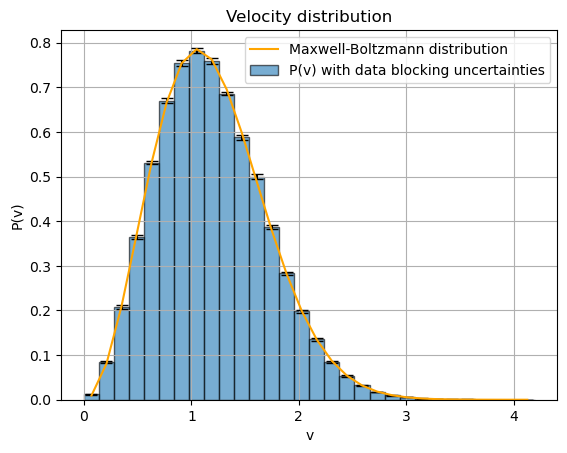

In [154]:
# Plot dei valori progressivi dell ultimo blocco per ciascun bin con relativa incertezza data dal data blocking

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PLOT DELLA DISTRIBUZIONE DEI MODULI DELLE VELOCITÀ DOPO N STEPS E USANDO COME VALORI DI P(v) QUELLI MEDI CALCOLATI SU TUTTI I BLOCKS CON ERRORE DI DATA BLOCKING

# Legge il file ignorando la riga di intestazione
data = pd.read_csv("Nsl_simulator_Ex_04_1/OUTPUT_Ex_04_1/pofv.dat", sep=r"\s+")

# Assegna i nomi alle colonne
data.columns = ["BLOCK", "VELOCITY", "ACTUAL_POFV", "AVE_POFV", "ERROR"]

# Seleziona l'ultimo blocco
last_block = data["BLOCK"].max()
last_data = data[data["BLOCK"] == last_block].copy()

# Larghezza del bin ricavata dai centri
dv = last_data["VELOCITY"].iloc[1] - last_data["VELOCITY"].iloc[0]

# Normalizzazione corretta per una distribuzione continua
norm = (last_data["AVE_POFV"] * dv).sum()
last_data["AVE_POFV"] = last_data["AVE_POFV"] / norm
last_data["ERROR"] = last_data["ERROR"] / norm

#distribuzione teorica di Maxwell-Boltzmann:
#Uso T dell'ultimo blocco per calcolare la distribuzione teorica
temp_data = pd.read_csv("Nsl_simulator_Ex_04_1/OUTPUT_Ex_04_1/temperature.dat", sep=r"\s+", comment="#", header=None, names=["BLOCK","ACTUAL_T","T_AVE","ERROR"])
last_block = data["BLOCK"].max()
T = temp_data.loc[temp_data["BLOCK"] == last_block, "T_AVE"].iloc[0]

# plot dei valori medi con barre d'errore
plt.bar(last_data["VELOCITY"], last_data["AVE_POFV"], width=dv, yerr=last_data["ERROR"], capsize=4, alpha=0.6, label='P(v) with data blocking uncertainties',edgecolor="black")
plt.plot(last_data["VELOCITY"], (4*np.pi*last_data["VELOCITY"]**2*np.exp(-last_data["VELOCITY"]**2/(2*T)))/((2*np.pi*T)**(3/2)), label="Maxwell-Boltzmann distribution", color='orange')

plt.xlabel("v")
plt.ylabel("P(v)")
plt.title("Velocity distribution")
plt.legend()
plt.grid(True)
plt.show()

### Comment

The plotted histogram is the final progressive blocked estimate of the speed distribution, obtained from `AVE_POFV` in the last block and then normalized in the notebook. The error bars are the progressive uncertainties produced by data blocking.

The comparison curve is the Maxwell-Boltzmann distribution in LJ reduced units,

$$
p(v^*,T^*) = \frac{4\pi (v^*)^2}{(2\pi T^*)^{3/2}}
\exp\left[-\frac{(v^*)^2}{2T^*}\right],
$$

using the final progressive temperature estimate read from the last block of `temperature.dat`, namely `T_AVE = 0.558617`. This value is used as $T^*$ in the Maxwell-Boltzmann distribution.

## EXERCISE 04.2

### Assignment prompt

By means of your upgraded code, perform MD simulations via a Lennard-Jones model ( e.g. Argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

starting from a **very low entropic** initial configuration:
1. initial **particle positions**: fcc crystal occupying half of the simulation box in each dimension
2. initial **velocity distribution**: $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$ where $v_{T^*}$ is suitably connected to $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

The goal is to show that, by evolving such initial condition via a Molecular Dynamics simulation, the velocity distribution tends to approximate the Maxwell–Boltzmann distribution.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.

### Method and initial conditions

This run uses the upgraded MD code to evolve a gas-phase Lennard-Jones system from a deliberately low-entropy initial condition. The input parameters are

```text
SIMULATION_TYPE        0
RESTART                0
TEMP                   2.0
NPART                  108
RHO                    0.05
R_CUT                  5.0
DELTA                  0.001
NBLOCKS                30
NSTEPS                 2000
```

The simulation is therefore an NVE Molecular Dynamics run in the gas phase. Here `RESTART = 0` is important: the code does not restart from two previously equilibrated configurations, but reads the initial FCC positions from `config.fcc` and builds the special initial state required by the assignment.

There is no preliminary equilibration before the production shown in this exercise, because the relaxation itself is the object of the study. The system starts from a very ordered state and the plots are used to follow how the velocity distribution approaches the Maxwell-Boltzmann form. Since the total energy is conserved in NVE, the temperature is not imposed during the evolution; the comparison with Maxwell-Boltzmann must be made using an effective temperature estimated from the relaxed part of the trajectory.

### C++ implementation: Low-entropy starting configuration

#### Initial configuration

The initial particle positions are handled in `System::read_configuration()`. The positions are read from `config.fcc`, but they are rescaled by `0.5*_side` instead of `_side`. This means that the FCC crystal initially occupies a region with half the box side in each spatial direction, corresponding to one eighth of the total box volume, as requested by the assignment:

```cpp
void System :: read_configuration(){
  ...
  cinf.open("../INPUT_Ex_04_2/CONFIG/config.fcc");
  ...
  _particle(i).setposition(0, this->pbc(0.5*_side(0)*x, 0));
  _particle(i).setposition(1, this->pbc(0.5*_side(1)*y, 1));
  _particle(i).setposition(2, this->pbc(0.5*_side(2)*z, 2));
  _particle(i).acceptmove();
  ...
}
```


#### Initial velocities

The initial velocities are modified in `System::initialize_velocities()`. The following code shows the `RESTART = 0` branch, where the special initial velocities required by the assignment are generated. For each particle only one velocity component is different from zero, with random direction and random sign:

```cpp
void System :: initialize_velocities(){
  double xold, yold, zold;

  if(_restart){
    ...
  } else { // RESTART = 0: special low-entropy velocity initialization

    vec vx(_npart), vy(_npart), vz(_npart);
    vec sumv(_ndim); // _ndim = 3
    sumv.zeros();

    double v_0 = sqrt(_temp);

    for (int i=0; i<_npart; i++){
      vx(i) = 0;
      vy(i) = 0;
      vz(i) = 0;

      int dir = int(_rnd.Rannyu(0.0,3.0));   // 0, 1, 2
      double sign;

      if (_rnd.Rannyu() < 0.5)
        sign = -1.0;
      else
        sign = 1.0;

      if(dir == 0) vx(i) = sign * v_0;
      if(dir == 1) vy(i) = sign * v_0;
      if(dir == 2) vz(i) = sign * v_0;

      sumv(0) += vx(i);
      sumv(1) += vy(i);
      sumv(2) += vz(i);
    }
    ...
  }
}
```

Still inside `System::initialize_velocities()`, the velocity initialization is completed by **two corrections**. First, the center-of-mass velocity is removed. Since the directions and signs of the initial velocities are chosen randomly, the total momentum of the system is not guaranteed to be exactly zero for a finite number of particles. This would produce an artificial global translation of the whole system, which is not related to the thermal motion of the gas. For this reason, the average velocity is computed and subtracted from every particle:

```cpp
for (int idim=0; idim<_ndim; idim++)
  sumv(idim) = sumv(idim)/double(_npart);

double sumv2 = 0.0;
double scalef;

for (int i=0; i<_npart; i++){
  vx(i) = vx(i) - sumv(0);
  vy(i) = vy(i) - sumv(1);
  vz(i) = vz(i) - sumv(2);

  sumv2 += vx(i) * vx(i) + vy(i) * vy(i) + vz(i) * vz(i);
}
```

After this operation, the total momentum is zero:

$$
\sum_i \vec v_i = 0.
$$

However, subtracting the center-of-mass velocity slightly changes the total kinetic energy. Therefore, the velocities are rescaled in order to recover the desired initial temperature. In reduced Lennard-Jones units, with $m=1$ and $k_B=1$, the equipartition theorem gives $\langle K \rangle = \frac{3}{2}T$ for the average kinetic energy per particle in three dimensions; since $\langle K \rangle = \frac{1}{2}\langle v^2 \rangle$, this gives $\langle v^2 \rangle = 3T$.


The code computes the mean value of $v^2$, builds the corresponding scale factor, and multiplies all velocities by the same factor:

```cpp
sumv2 /= double(_npart);
scalef = sqrt(3.0 * _temp / sumv2);

for (int i=0; i<_npart; i++){
  _particle(i).setvelocity(0, vx(i)*scalef);
  _particle(i).setvelocity(1, vy(i)*scalef);
  _particle(i).setvelocity(2, vz(i)*scalef);
}
```

Finally, the previous-time-step configuration is constructed. This is necessary because the Verlet algorithm is not self-starting: it updates the positions using both the current and the previous configurations,

$$
\vec r(t+\Delta t)
=
2\vec r(t)-\vec r(t-\Delta t)+\vec a(t)\Delta t^2.
$$

At the beginning of the simulation, the current positions $\vec r(t)$ and the velocities $\vec v(t)$ are known, but the previous positions $\vec r(t-\Delta t)$ are not. They are therefore approximated by taking one small step backward using the initialized velocities:

$$
\vec r(t-\Delta t) \simeq \vec r(t)-\vec v(t)\Delta t.
$$

In the code this is done as follows:

```cpp
for (int i=0; i<_npart; i++){
  xold = this->pbc(_particle(i).getposition(0,true)
                   - _particle(i).getvelocity(0)*_delta, 0);
  yold = this->pbc(_particle(i).getposition(1,true)
                   - _particle(i).getvelocity(1)*_delta, 1);
  zold = this->pbc(_particle(i).getposition(2,true)
                   - _particle(i).getvelocity(2)*_delta, 2);

  _particle(i).setpositold(0, xold);
  _particle(i).setpositold(1, yold);
  _particle(i).setpositold(2, zold);
}
```

The function `pbc` applies periodic boundary conditions, so that the reconstructed previous positions remain inside the simulation box. After this initialization, the Verlet integration can start from a physically consistent non-equilibrium state.

### Results: velocity distribution

The velocity distributions are plotted using `AVE_POFV`, the progressive blocked estimate of $P(v)$. The simulation is divided into **30** blocks of **2000 MD steps** each. For this reason, the histogram associated with a given block includes the statistical contribution of all previous blocks up to that point. The plot therefore shows the evolution of the progressive estimate during the simulation.

The Maxwell-Boltzmann curve is computed using a single effective temperature $T^*_{\mathrm{eff}}$, estimated from the relaxed part of the trajectory, rather than using the initial input value $T^*=2.0$ or a different temperature for each block.

C:\Users\tomma\AppData\Local\Temp\ipykernel_9584\3041507930.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


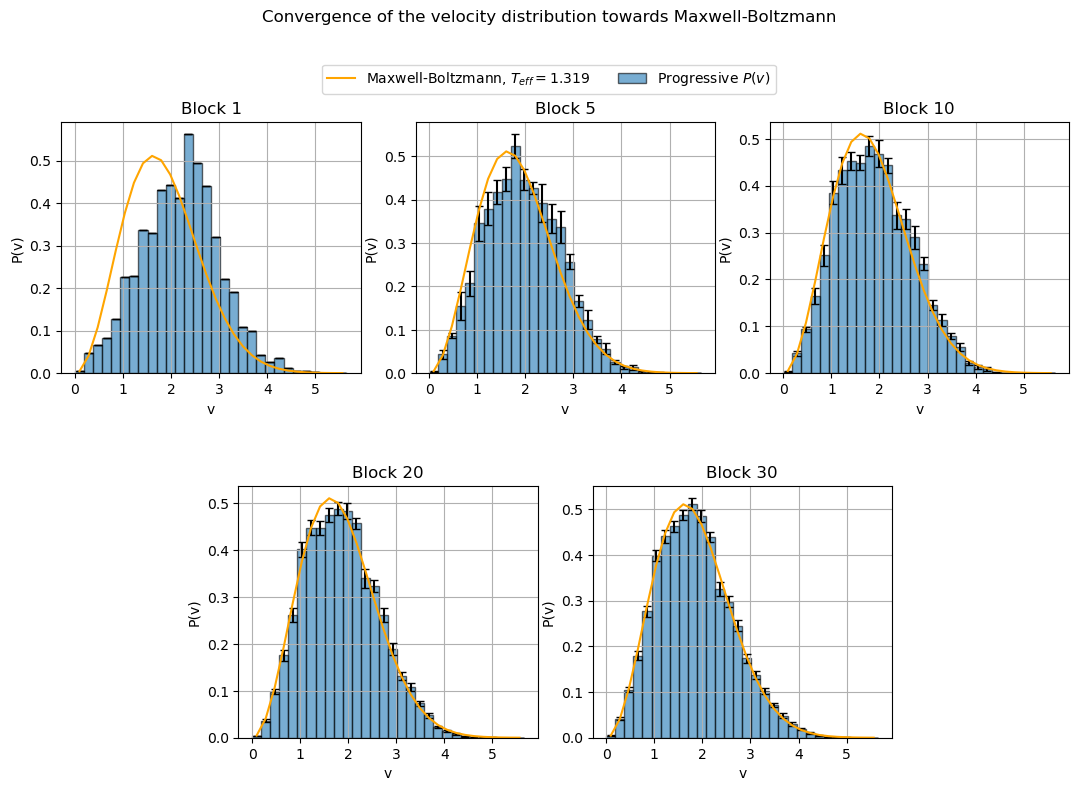

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PLOT DELLA DISTRIBUZIONE DEI MODULI DELLE VELOCITÀ IN ALCUNI BLOCCHI,
# PER VISUALIZZARE LA CONVERGENZA VERSO MAXWELL-BOLTZMANN
# 30 blocchi: 2000 step ciascuno

data = pd.read_csv("Nsl_simulator_Ex_04_2/OUTPUT_Ex_04_2/pofv.dat", sep=r"\s+")
data.columns = ["BLOCK", "VELOCITY", "ACTUAL_POFV", "AVE_POFV", "ERROR"]

temp_data = pd.read_csv(
    "Nsl_simulator_Ex_04_2/OUTPUT_Ex_04_2/temperature.dat",
    sep=r"\s+",
    comment="#",
    header=None,
    names=["BLOCK", "ACTUAL_T", "T_AVE", "ERROR"]
)

# Temperatura efficace stimata dalla parte rilassata della traiettoria
# Qui vengono usati gli ultimi 5 blocchi come regime rilassato
last_block = temp_data["BLOCK"].max()
relaxed_blocks = temp_data[temp_data["BLOCK"] > last_block - 5]
T_eff = relaxed_blocks["ACTUAL_T"].mean()

selected_blocks = [1, 5, 10, 20, 30]

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 6, hspace=0.45, wspace=0.45)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5])
]

for i, blk in enumerate(selected_blocks):
    block_data = data[data["BLOCK"] == blk].copy()

    dv = block_data["VELOCITY"].iloc[1] - block_data["VELOCITY"].iloc[0]

    norm = (block_data["AVE_POFV"] * dv).sum()
    block_data["AVE_POFV"] = block_data["AVE_POFV"] / norm
    block_data["ERROR"] = block_data["ERROR"] / norm

    axes[i].bar(
        block_data["VELOCITY"],
        block_data["AVE_POFV"],
        width=dv,
        yerr=block_data["ERROR"],
        capsize=3,
        alpha=0.6,
        edgecolor="black",
        label="Progressive $P(v)$"
    )

    axes[i].plot(
        block_data["VELOCITY"],
        (4*np.pi*block_data["VELOCITY"]**2*np.exp(-block_data["VELOCITY"]**2/(2*T_eff))) / ((2*np.pi*T_eff)**(3/2)),
        label=fr"Maxwell-Boltzmann, $T_{{eff}}={T_eff:.3f}$",
        color="orange"
    )

    axes[i].set_title(f"Block {blk}")
    axes[i].set_xlabel("v")
    axes[i].set_ylabel("P(v)")
    axes[i].grid(True)

# Una sola legenda globale, fuori dai pannelli
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.96))

fig.suptitle("Convergence of the velocity distribution towards Maxwell-Boltzmann", y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

#### Comment

The panels show how the progressive estimate of the velocity distribution evolves during the same MD trajectory. At the beginning, the estimate is still strongly affected by the artificial low-entropy initialization, where each particle has only one non-zero velocity component. As the simulation proceeds, particle interactions redistribute the kinetic energy among the three components and the accumulated velocity distribution becomes progressively closer to the Maxwell-Boltzmann shape.

The Maxwell-Boltzmann curve shown in the panels is not computed using the initial input value $T^*=2.0$. Instead, the same effective temperature $T^*_{\mathrm{eff}}$ is used in all panels. This temperature is estimated from the relaxed part of the MD trajectory, here by averaging the block temperatures `ACTUAL_T` over the last five blocks. With 30 total blocks, this corresponds to blocks 26--30. This follows the assignment note: in an NVE simulation the total energy is conserved, but kinetic and potential energy can be exchanged, so the relevant equilibrium comparison is made with $p(v^*,T^*_{\mathrm{eff}})$.

### Results: temperature and potential energy evolution

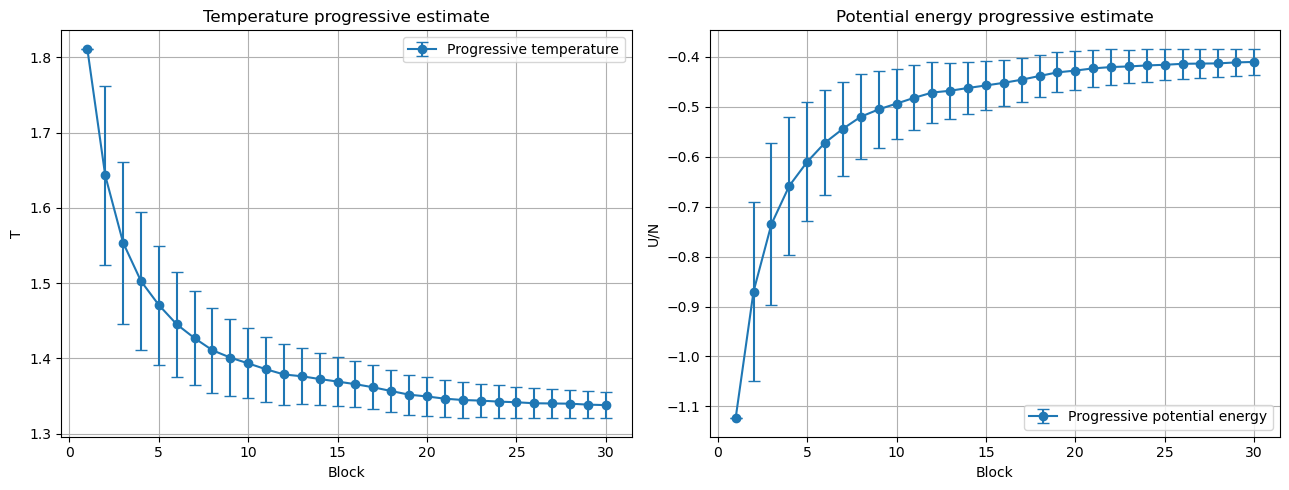

In [156]:
# PLOT DELLA TEMPERATURA E DELL'ENERGIA POTENZIALE IN FUNZIONE DEL BLOCCO,
# PER MOSTRARE COME EVOLVONO LE STIME PROGRESSIVE DURANTE LA SIMULAZIONE

# Legge il file della temperatura
temp_data = pd.read_csv(
    "Nsl_simulator_Ex_04_2/OUTPUT_Ex_04_2/temperature.dat",
    sep=r"\s+",
    comment="#",
    header=None,
    names=["BLOCK", "ACTUAL_T", "T_AVE", "ERROR"]
)

# Legge il file dell'energia potenziale
pot_data = pd.read_csv(
    "Nsl_simulator_Ex_04_2/OUTPUT_Ex_04_2/potential_energy.dat",
    sep=r"\s+",
    comment="#",
    header=None,
    names=["BLOCK", "ACTUAL_PE", "PE_AVE", "ERROR"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Temperatura media progressiva
axes[0].errorbar(
    temp_data["BLOCK"],
    temp_data["T_AVE"],
    yerr=temp_data["ERROR"],
    fmt="o-",
    capsize=4,
    label="Progressive temperature"
)

axes[0].set_xlabel("Block")
axes[0].set_ylabel("T")
axes[0].set_title("Temperature progressive estimate")
axes[0].legend()
axes[0].grid(True)

# Energia potenziale media progressiva
axes[1].errorbar(
    pot_data["BLOCK"],
    pot_data["PE_AVE"],
    yerr=pot_data["ERROR"],
    fmt="o-",
    capsize=4,
    label="Progressive potential energy"
)

axes[1].set_xlabel("Block")
axes[1].set_ylabel("U/N")
axes[1].set_title("Potential energy progressive estimate")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Comment

The temperature and potential energy plots are shown to monitor how the progressive thermodynamic estimates evolve during the relaxation from the special initial condition, before comparing the measured velocity histograms with the theoretical Maxwell-Boltzmann distribution.

The plots show the progressive block averages `T_AVE` and `PE_AVE`, with their data-blocking uncertainties. These quantities are useful to see how the statistical estimates evolve during the run and whether they approach a more stable regime after the initial non-equilibrium transient.

In an NVE simulation the total energy is conserved, while kinetic and potential energy can be exchanged during the dynamics. Therefore, the temperature, which is related to the kinetic energy, is not fixed by the input value throughout the trajectory. For this reason, the Maxwell-Boltzmann comparison above uses an effective temperature $T^*_{\mathrm{eff}}$ estimated from the relaxed part of the trajectory, by averaging the block temperatures `ACTUAL_T` over the last five blocks, corresponding here to blocks 26--30, rather than simply using the initial input value $T^*=2.0$.

### The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time?

Yes, the forward evolution is expected to move towards a higher-entropy macroscopic state. Initially, the particles occupy only a fraction of the available volume and the velocities have a very artificial structure: each particle has only one non-zero component. During the MD evolution, particle collisions redistribute energy among the three components and the system explores a much larger region of phase space. As a result, the velocity distribution becomes closer to the Maxwell-Boltzmann form and the spatial configuration becomes more homogeneous.

If the direction of time were reversed exactly, the microscopic equations of motion would in principle allow the trajectory to return to the initial low-entropy configuration. In practice, however, this requires an extremely precise inversion of the microscopic state. In a numerical simulation, even very small numerical errors are rapidly amplified by the chaotic sensitivity to initial conditions. Therefore, after a sufficiently long forward evolution, the reversed trajectory is not expected to reconstruct the initial low-entropy state exactly.

## EXERCISE 04.3

### Assignment prompt

Starting from the **final states** of two MD simulations of the system in Exercise 04.2, one with about $5\times 10^3$ time-steps the other with about $5\times 10^4$ time-steps, by changing the direction of time (e.g. by inverting the final velocities), try to return back to the very low entropic initial configuration of Exercise 04.2. Is this possible? (for example, one can monitor the behavior of the average **potential energy** and the average **temperature** in **each block** as a function of time going **in both directions**. Show some picture and comment on what you find in your jupyter-notebook.

### Method and simulation setup

The time-reversal test starts from the same type of low-entropy initial state used in Exercise 04.2. Two forward Molecular Dynamics simulations are considered:

- about $5\times 10^3$ time steps;
- about $5\times 10^4$ time steps.

The input file for the long run uses **250 blocks** of **200** steps which gives $250\times 200 = 5.0\times 10^4$ time steps. The shorter run corresponds to **25** blocks of **200** steps, i.e. $5.0\times 10^3$ steps.

In this exercise `properties.dat` contains only the thermodynamic observables needed for the comparison, so `POFV` is not measured here.

The plotted quantities are the block averages `ACTUAL_TEMP` and `ACTUAL_PE`, not the progressive averages. This choice is appropriate here because the goal is to monitor the time evolution of the system during the forward and reversed dynamics. Progressive averages would mix different time windows and would partially hide the reconstruction behavior.

The forward run is performed with `RESTART = 0`, exactly as in Exercise 04.2. Therefore, the same low-entropy initial condition is used: an FCC configuration compressed into half of the box in each spatial direction, together with the special non-equilibrium velocity distribution.

For the reversed evolution, the correct implementation must take into account that the Verlet algorithm advances the trajectory using two consecutive configurations. If the forward simulation ends with

$$
\texttt{config.xyz}=\vec r_N,
\qquad
\texttt{conf-1.xyz}=\vec r_{N-1},
$$

the reverse simulation is initialized by exchanging their roles:

$$
\vec r_{\text{current}}=\vec r_{N-1},
\qquad
\vec r_{\text{old}}=\vec r_N.
$$

This reverses the direction of the discrete Verlet trajectory because the velocity information is implicitly contained in the difference between two successive positions. No additional equilibration is performed before reversing: the goal is precisely to test whether the numerical trajectory can go back to the original low-entropy state.

### C++ implementation

For `RESTART = 0`, the initialization is the same as in Exercise 04.2 and produces the low-entropy starting state. The new point in this exercise is the `RESTART = 1` branch, which is used to reverse the Verlet trajectory.

For `RESTART = 1`, the corrected time-reversal implementation follows the standard Verlet restart structure: `read_configuration()` reads `config.xyz`, while `initialize_velocities()` reads `conf-1.xyz` and stores it as the previous-time-step configuration.

```cpp
if(_restart){
  ifstream cinf;
  cinf.open("../INPUT_Ex_04_3/CONFIG/conf-1.xyz");

  if(cinf.is_open()){
    string comment;
    string particle;
    int ncoord;
    cinf >> ncoord;
    cinf >> comment;

    for(int i=0; i<_npart; i++){
      cinf >> particle >> xold >> yold >> zold;
      _particle(i).setpositold(0, this->pbc(_side(0)*xold, 0));
      _particle(i).setpositold(1, this->pbc(_side(1)*yold, 1));
      _particle(i).setpositold(2, this->pbc(_side(2)*zold, 2));
    }
  }
}
```

The reversal is then performed at the level of the input configurations. For example, for the short trajectory:

```bash
cp OUTPUT_forward_5e3/CONFIG/conf-1.xyz INPUT_Ex_04_3/CONFIG/config.xyz
cp OUTPUT_forward_5e3/CONFIG/config.xyz INPUT_Ex_04_3/CONFIG/conf-1.xyz
```

The same procedure is used for the long trajectory. In this way, the reversed simulation starts from the two final configurations of the forward trajectory with their order exchanged, which is the natural way to reverse a Verlet trajectory.

### Results

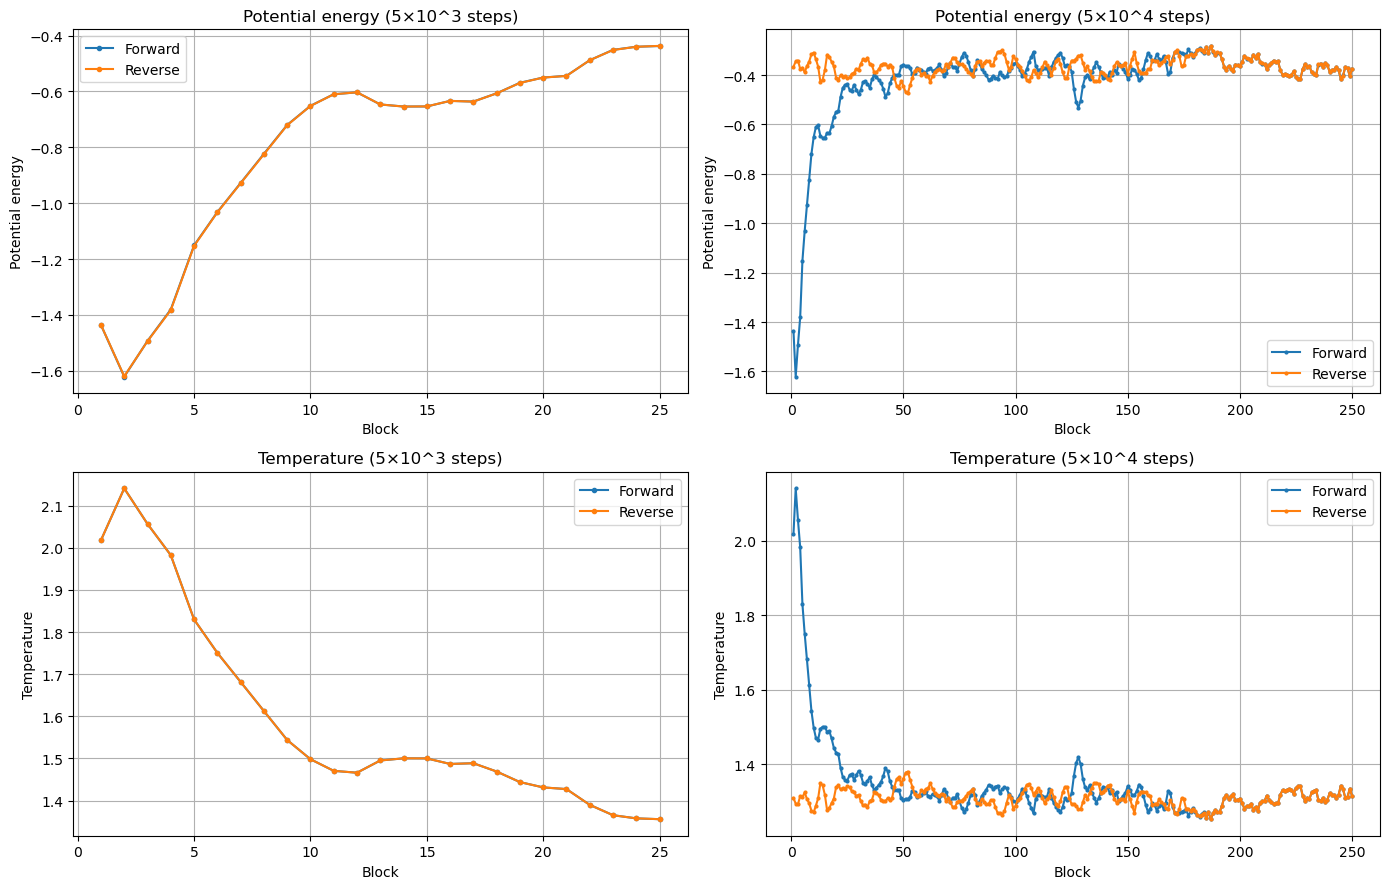

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#short: 25 blocks of 200 steps -> 5e3 steps
#long: 250 blocks of 200 steps -> 5e4 steps

def read_md_output(filepath, value_name):
    return pd.read_csv(
        filepath,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["BLOCK", f"ACTUAL_{value_name}", f"{value_name}_AVE", "ERROR"]
    )

def load_case(base_path):
    pot = read_md_output(f"{base_path}/potential_energy.dat", "PE")
    temp = read_md_output(f"{base_path}/temperature.dat", "TEMP")
    return pot, temp

def reverse_in_time(df, actual_col):
    out = pd.DataFrame()
    out["BLOCK"] = np.arange(1, len(df) + 1)
    out[actual_col] = df[actual_col].iloc[::-1].values
    return out

# Percorsi
# Paths for the correct Verlet time-reversal test
forward_5e3_path = "Nsl_simulator_Ex_04_3_correct_reverse/OUTPUT_forward_5e3"
reverse_5e3_path = "Nsl_simulator_Ex_04_3_correct_reverse/OUTPUT_reverse_swap_5e3"

forward_5e4_path = "Nsl_simulator_Ex_04_3_correct_reverse/OUTPUT_forward_5e4"
reverse_5e4_path = "Nsl_simulator_Ex_04_3_correct_reverse/OUTPUT_reverse_swap_5e4"

# Caricamento dati
fwd_pot_5e3, fwd_temp_5e3 = load_case(forward_5e3_path)
rev_pot_5e3, rev_temp_5e3 = load_case(reverse_5e3_path)

fwd_pot_5e4, fwd_temp_5e4 = load_case(forward_5e4_path)
rev_pot_5e4, rev_temp_5e4 = load_case(reverse_5e4_path)

# Reverse ribaltata nel tempo
rev_pot_5e3_rt = reverse_in_time(rev_pot_5e3, "ACTUAL_PE")
rev_temp_5e3_rt = reverse_in_time(rev_temp_5e3, "ACTUAL_TEMP")

rev_pot_5e4_rt = reverse_in_time(rev_pot_5e4, "ACTUAL_PE")
rev_temp_5e4_rt = reverse_in_time(rev_temp_5e4, "ACTUAL_TEMP")

# Figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Potential energy, 5e3
axes[0, 0].plot(fwd_pot_5e3["BLOCK"], fwd_pot_5e3["ACTUAL_PE"], "-o", ms=3, label="Forward")
axes[0, 0].plot(rev_pot_5e3_rt["BLOCK"], rev_pot_5e3_rt["ACTUAL_PE"], "-o", ms=3, label="Reverse")
axes[0, 0].set_title("Potential energy (5×10^3 steps)")
axes[0, 0].set_xlabel("Block")
axes[0, 0].set_ylabel("Potential energy")
axes[0, 0].grid(True)
axes[0, 0].legend()

# Potential energy, 5e4
axes[0, 1].plot(fwd_pot_5e4["BLOCK"], fwd_pot_5e4["ACTUAL_PE"], "-o", ms=2, label="Forward")
axes[0, 1].plot(rev_pot_5e4_rt["BLOCK"], rev_pot_5e4_rt["ACTUAL_PE"], "-o", ms=2, label="Reverse")
axes[0, 1].set_title("Potential energy (5×10^4 steps)")
axes[0, 1].set_xlabel("Block")
axes[0, 1].set_ylabel("Potential energy")
axes[0, 1].grid(True)
axes[0, 1].legend()

# Temperature, 5e3
axes[1, 0].plot(fwd_temp_5e3["BLOCK"], fwd_temp_5e3["ACTUAL_TEMP"], "-o", ms=3, label="Forward")
axes[1, 0].plot(rev_temp_5e3_rt["BLOCK"], rev_temp_5e3_rt["ACTUAL_TEMP"], "-o", ms=3, label="Reverse")
axes[1, 0].set_title("Temperature (5×10^3 steps)")
axes[1, 0].set_xlabel("Block")
axes[1, 0].set_ylabel("Temperature")
axes[1, 0].grid(True)
axes[1, 0].legend()

# Temperature, 5e4
axes[1, 1].plot(fwd_temp_5e4["BLOCK"], fwd_temp_5e4["ACTUAL_TEMP"], "-o", ms=2, label="Forward")
axes[1, 1].plot(rev_temp_5e4_rt["BLOCK"], rev_temp_5e4_rt["ACTUAL_TEMP"], "-o", ms=2, label="Reverse")
axes[1, 1].set_title("Temperature (5×10^4 steps)")
axes[1, 1].set_xlabel("Block")
axes[1, 1].set_ylabel("Temperature")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Comment

For the shorter trajectory, around $5\times 10^3$ integration steps, the reversed evolution follows the forward one very closely when it is plotted in the opposite time direction.

For the longer trajectory, around $5\times 10^4$ integration steps, the mismatch becomes much clearer. The reversed evolution remains close to the equilibrated gas-like regime and does not reconstruct the initial low-entropy stage of the forward run. This does not mean that the low-entropy state is dynamically forbidden: a perfectly reversed microscopic state would in principle return to it. However, such a return requires an extremely precise microscopic reversal.

It is important to distinguish two different numerical issues. The Verlet algorithm is itself time-reversal symmetric: if the two consecutive configurations are exchanged exactly, the discrete Verlet trajectory should be followed backward. The truncation error of the algorithm, obtained from the Taylor expansion,

$$
\vec r(t+\Delta t)=2\vec r(t)-\vec r(t-\Delta t)+\vec a(t)\Delta t^2+O(\Delta t^4),
$$

means that Verlet approximates the exact continuous trajectory with a finite time step. This error affects the numerical trajectory with respect to the **real** continuous dynamics, but it is not the reason why the forward and reversed discrete trajectories fail to overlap. In exact arithmetic, the same discrete approximation would be made in both time directions.

The loss of reconstruction is instead due to **round-off errors** and tiny inaccuracies in the numerical state used for the reversal. In a chaotic many-particle system, these very small differences are rapidly amplified. Since the initial configuration is a very special low-entropy state, it corresponds to an extremely small and statistically unlikely region of phase space. Therefore, even a tiny numerical mismatch is enough to prevent the system from returning exactly to that state after a long evolution.

If the initial state were a more typical equilibrium configuration, the forward and reversed microscopic trajectories would still separate because of chaotic sensitivity. However, the macroscopic difference would likely be less dramatic, because the system would remain within the same equilibrium-like region of phase space. In the present case, the failure is much more visible because the target state is a highly ordered, very low-entropy configuration.

### Different implementation: velocity-inversion attempt

A previous implementation of the time reversal tried to reverse the dynamics by saving the final velocities, changing their sign and reconstructing the previous-time-step configuration from the inverted velocities.

```cpp
_particle(i).setvelocity(0, -vx);
_particle(i).setvelocity(1, -vy);
_particle(i).setvelocity(2, -vz);

xold = this->pbc(_particle(i).getposition(0,true)
                 - _particle(i).getvelocity(0)*_delta, 0);
```

This idea is physically related to velocity inversion, but it is not the cleanest way to reverse a Verlet trajectory, because Verlet propagates the dynamics using two consecutive position configurations.

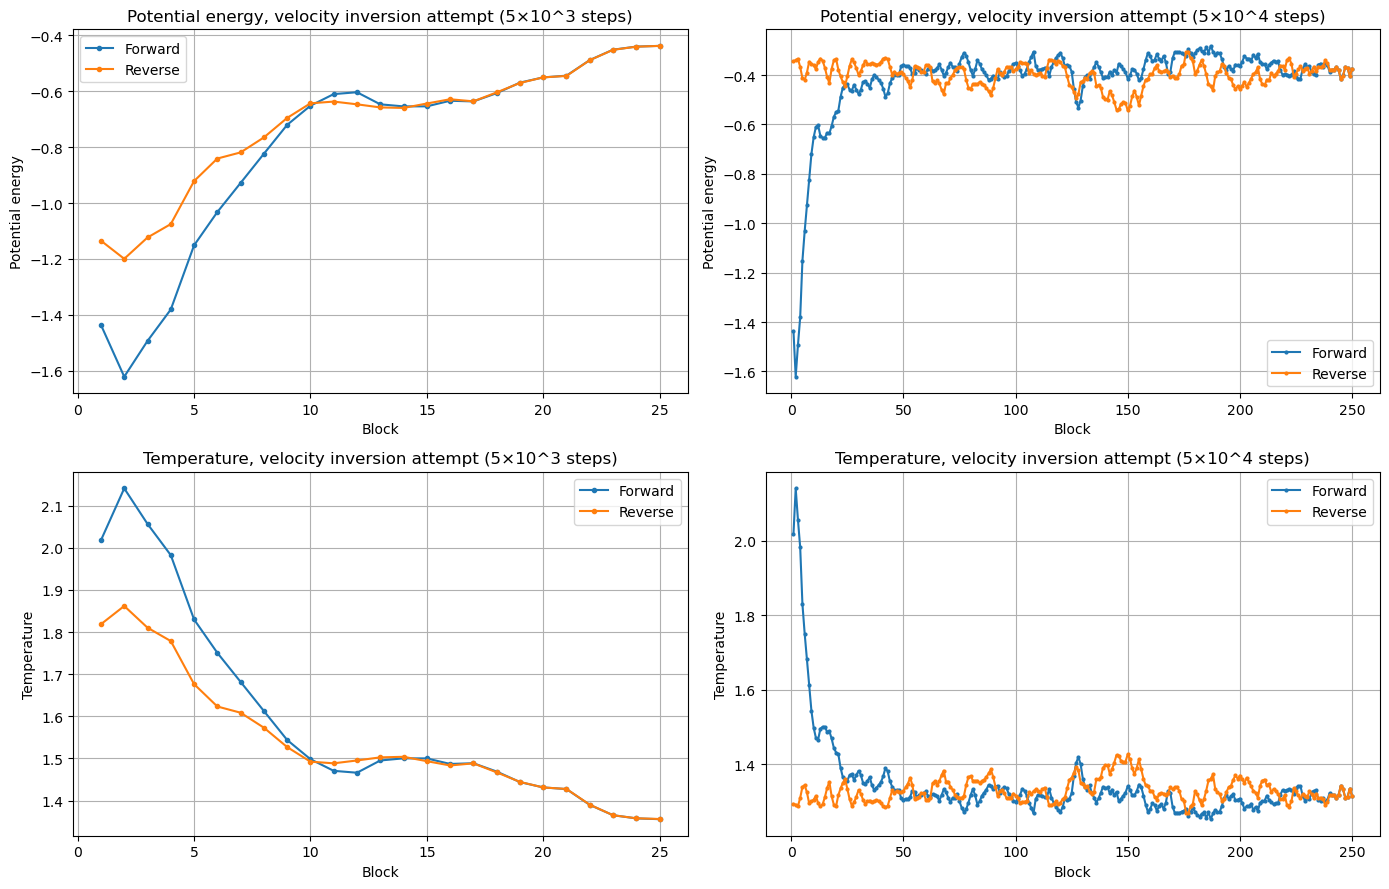

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def read_md_output_attempt(filepath, value_name):
    return pd.read_csv(
        filepath,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["BLOCK", f"ACTUAL_{value_name}", f"{value_name}_AVE", "ERROR"]
    )

def load_case_attempt(base_path):
    pot = read_md_output_attempt(f"{base_path}/potential_energy.dat", "PE")
    temp = read_md_output_attempt(f"{base_path}/temperature.dat", "TEMP")
    return pot, temp

def reverse_in_time_attempt(df, actual_col):
    reversed_df = pd.DataFrame()
    reversed_df["BLOCK"] = np.arange(1, len(df) + 1)
    reversed_df[actual_col] = df[actual_col].iloc[::-1].values
    return reversed_df

# Paths for the velocity-inversion attempt
forward_5e3_path = "Nsl_simulator_Ex_04_3_attempt_reverse/OUTPUT_forward_5e3"
reverse_5e3_path = "Nsl_simulator_Ex_04_3_attempt_reverse/OUTPUT_reverse_5e3"

forward_5e4_path = "Nsl_simulator_Ex_04_3_attempt_reverse/OUTPUT_forward_5e4"
reverse_5e4_path = "Nsl_simulator_Ex_04_3_attempt_reverse/OUTPUT_reverse_5e4"

# Load data
fwd_pot_5e3, fwd_temp_5e3 = load_case_attempt(forward_5e3_path)
rev_pot_5e3, rev_temp_5e3 = load_case_attempt(reverse_5e3_path)

fwd_pot_5e4, fwd_temp_5e4 = load_case_attempt(forward_5e4_path)
rev_pot_5e4, rev_temp_5e4 = load_case_attempt(reverse_5e4_path)

# Reverse data displayed in opposite block order
rev_pot_5e3_rt = reverse_in_time_attempt(rev_pot_5e3, "ACTUAL_PE")
rev_temp_5e3_rt = reverse_in_time_attempt(rev_temp_5e3, "ACTUAL_TEMP")

rev_pot_5e4_rt = reverse_in_time_attempt(rev_pot_5e4, "ACTUAL_PE")
rev_temp_5e4_rt = reverse_in_time_attempt(rev_temp_5e4, "ACTUAL_TEMP")

# Figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Potential energy, 5e3
axes[0, 0].plot(fwd_pot_5e3["BLOCK"], fwd_pot_5e3["ACTUAL_PE"], "-o", ms=3, label="Forward")
axes[0, 0].plot(rev_pot_5e3_rt["BLOCK"], rev_pot_5e3_rt["ACTUAL_PE"], "-o", ms=3, label="Reverse")
axes[0, 0].set_title("Potential energy, velocity inversion attempt (5×10^3 steps)")
axes[0, 0].set_xlabel("Block")
axes[0, 0].set_ylabel("Potential energy")
axes[0, 0].grid(True)
axes[0, 0].legend()

# Potential energy, 5e4
axes[0, 1].plot(fwd_pot_5e4["BLOCK"], fwd_pot_5e4["ACTUAL_PE"], "-o", ms=2, label="Forward")
axes[0, 1].plot(rev_pot_5e4_rt["BLOCK"], rev_pot_5e4_rt["ACTUAL_PE"], "-o", ms=2, label="Reverse")
axes[0, 1].set_title("Potential energy, velocity inversion attempt (5×10^4 steps)")
axes[0, 1].set_xlabel("Block")
axes[0, 1].set_ylabel("Potential energy")
axes[0, 1].grid(True)
axes[0, 1].legend()

# Temperature, 5e3
axes[1, 0].plot(fwd_temp_5e3["BLOCK"], fwd_temp_5e3["ACTUAL_TEMP"], "-o", ms=3, label="Forward")
axes[1, 0].plot(rev_temp_5e3_rt["BLOCK"], rev_temp_5e3_rt["ACTUAL_TEMP"], "-o", ms=3, label="Reverse")
axes[1, 0].set_title("Temperature, velocity inversion attempt (5×10^3 steps)")
axes[1, 0].set_xlabel("Block")
axes[1, 0].set_ylabel("Temperature")
axes[1, 0].grid(True)
axes[1, 0].legend()

# Temperature, 5e4
axes[1, 1].plot(fwd_temp_5e4["BLOCK"], fwd_temp_5e4["ACTUAL_TEMP"], "-o", ms=2, label="Forward")
axes[1, 1].plot(rev_temp_5e4_rt["BLOCK"], rev_temp_5e4_rt["ACTUAL_TEMP"], "-o", ms=2, label="Reverse")
axes[1, 1].set_title("Temperature, velocity inversion attempt (5×10^4 steps)")
axes[1, 1].set_xlabel("Block")
axes[1, 1].set_ylabel("Temperature")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

With the velocity-inversion attempt, the short trajectory still goes reasonably close to the forward evolution when plotted in the opposite time direction, but the reconstruction is visibly worse than with the configuration-swap method. The reason is that, in this implementation, the reversed Verlet pair is not obtained directly from the two final configurations of the forward run. Instead, the **old position is reconstructed from the saved velocities after changing their sign**. This introduces an additional numerical approximation at the very beginning of the reversed run. Since the system is chaotic, even a very small initial mismatch is amplified during the dynamics.

For the shorter trajectory, around $5\times 10^3$ time steps, this extra error is still small, so the reversed evolution remains quite close to the forward one.

For the longer trajectory, around $5\times 10^4$ time steps, the initial mismatch has much more time to grow. As a result, the system does not return to the initial low-entropy state at all.